<a href="https://colab.research.google.com/github/stilgoin/demo2/blob/master/Copy_of_tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utilsforecast.plotting import plot_series
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import *

import warnings
warnings.filterwarnings("ignore")

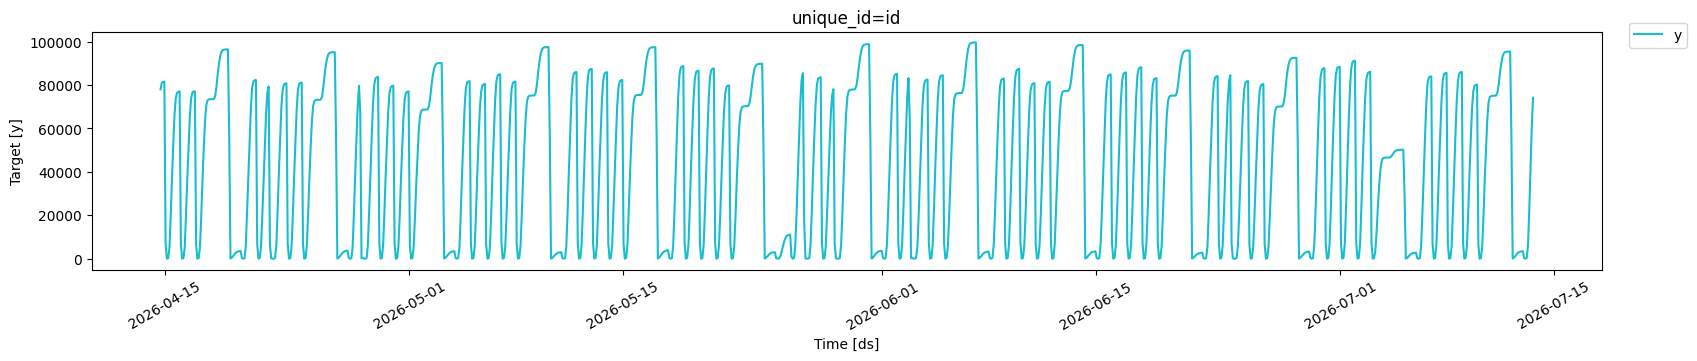

In [ ]:
df = pd.read_csv("sample_data/received2.csv")
#df = df.groupby('unique_id').filter(lambda x: len(x) >= 28)
#df = df.drop(["unit_price"], axis=1)
df = df.rename(columns={'Time':'ds','Received':'y'})

df['ds'] = pd.to_datetime(df['ds'])
df['unique_id'] = 'id'
plot_series(df=df)

In [ ]:
from statsforecast import StatsForecast
from statsforecast.models import Naive, HistoricAverage, WindowAverage, SeasonalNaive

In [ ]:
horizon = 540

models = [
    Naive(),
    HistoricAverage(),
    WindowAverage(window_size=horizon),
    SeasonalNaive(season_length=horizon)
]

In [ ]:
sf = StatsForecast(models=models, freq="H")

In [ ]:
sf.fit(df=df)

StatsForecast(models=[Naive,HistoricAverage,WindowAverage,SeasonalNaive])

In [ ]:
preds = sf.predict(h=horizon)

In [ ]:
preds.head()

,unique_id,ds,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,id,2026-07-13 16:00:00,74100.0,44189.525926,43475.063636,19400.0
1,id,2026-07-13 17:00:00,74100.0,44189.525926,43475.063636,37100.0
2,id,2026-07-13 18:00:00,74100.0,44189.525926,43475.063636,53100.0
3,id,2026-07-13 19:00:00,74100.0,44189.525926,43475.063636,67900.0
4,id,2026-07-13 20:00:00,74100.0,44189.525926,43475.063636,77000.0


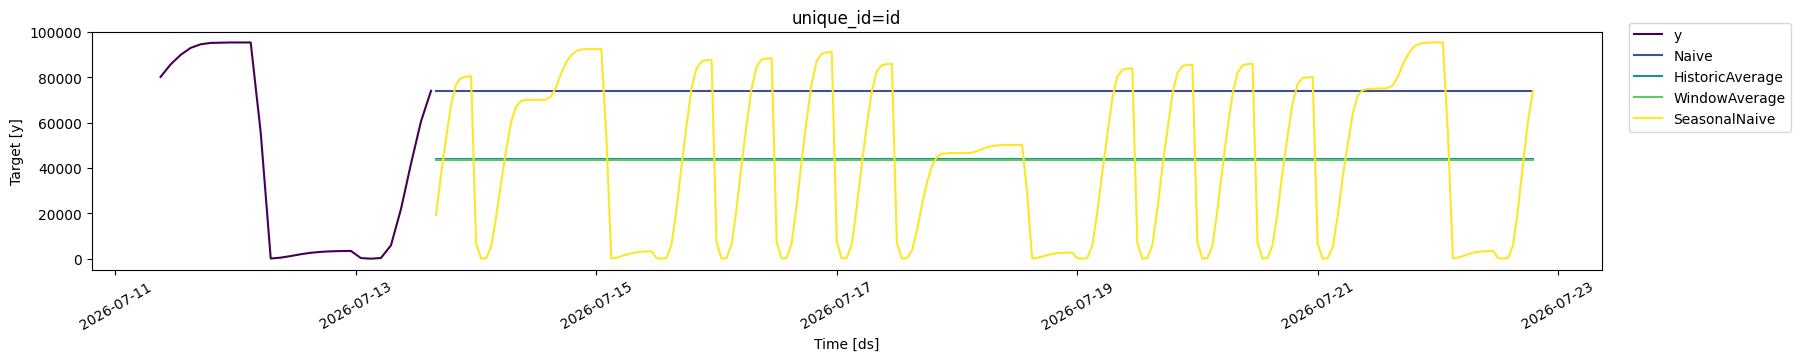

In [ ]:
plot_series(
    df=df,
    forecasts_df=preds,
    ids=["id"],
    max_insample_length=28,
    palette="viridis")

In [ ]:
test = df.groupby("unique_id").tail(7)
train = df.drop(test.index).reset_index(drop=True)

In [ ]:
sf.fit(df=train)

preds = sf.predict(h=horizon)

eval_df = pd.merge(test, preds, 'left', ['ds', 'unique_id'])

In [ ]:
evaluation = evaluate(
    eval_df,
    metrics=[mae],
)
evaluation.head()

,unique_id,metric,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,id,mae,29027.5,28212.771934,27966.820779,18584.071429


In [ ]:
evaluation = evaluation.drop(['unique_id'], axis=1).groupby('metric').mean().reset_index()
evaluation

,metric,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,mae,29027.5,28212.771934,27966.820779,18584.071429


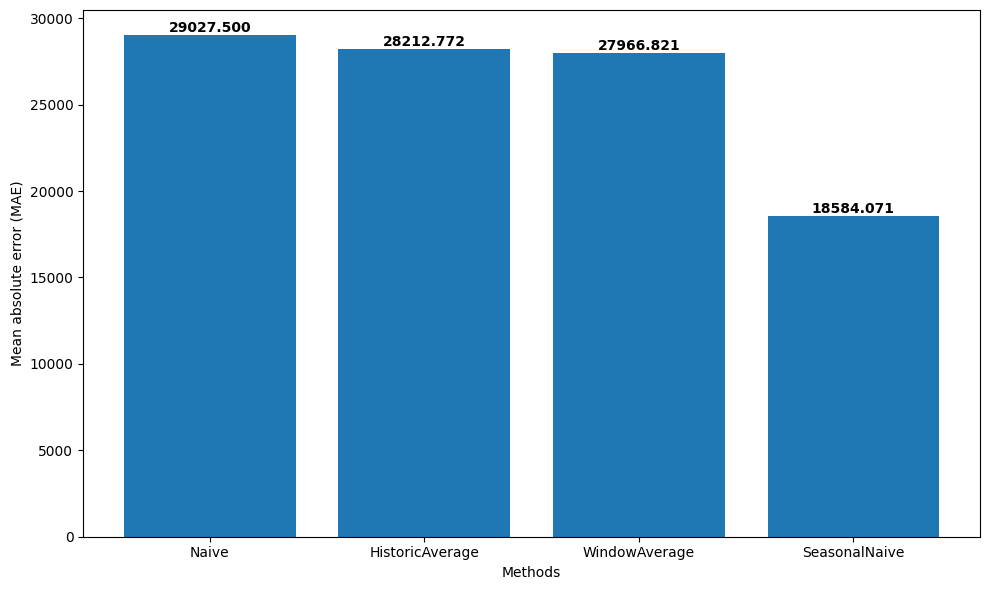

In [ ]:
methods = evaluation.columns[1:].tolist()
values = evaluation.iloc[0, 1:].tolist()

plt.figure(figsize=(10, 6))
bars = plt.bar(methods, values)

for bar, value in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

plt.xlabel('Methods')
plt.ylabel('Mean absolute error (MAE)')
plt.tight_layout()

plt.show()

In [ ]:
from statsforecast.models import AutoARIMA

In [ ]:
unique_ids = ["id"]

small_train = train[train["unique_id"].isin(unique_ids)]
#small_train = train[train.index < 75]
small_test = test[test["unique_id"].isin(unique_ids)]

models = [
    AutoARIMA(seasonal=False, alias="ARIMA"),
    AutoARIMA(season_length=15, alias="SARIMA")
]

sf = StatsForecast(models=models, freq="H")
sf.fit(df=small_train)
arima_preds = sf.predict(h=150)

arima_eval_df = pd.merge(arima_preds, eval_df, 'inner', ['ds', 'unique_id'])
arima_eval = evaluate(
    arima_eval_df,
    metrics=[mae],
)
arima_eval

In [ ]:
arima_preds

,unique_id,ds,ARIMA
0,id,2026-07-13 02:00:00,4661.601509
1,id,2026-07-13 03:00:00,5198.950425
2,id,2026-07-13 04:00:00,9208.448857
3,id,2026-07-13 05:00:00,12610.117509
4,id,2026-07-13 06:00:00,18357.577048
...,...,...,...
145,id,2026-07-19 03:00:00,43113.437157
146,id,2026-07-19 04:00:00,42476.804278
147,id,2026-07-19 05:00:00,42334.068909
148,id,2026-07-19 06:00:00,42712.059404


In [ ]:
arima_eval = arima_eval.drop(['unique_id'], axis=1).groupby('metric').mean().reset_index()
arima_eval

,metric,ARIMA,Naive,HistoricAverage,WindowAverage,SeasonalNaive
0,mae,16786.074244,29027.5,28212.771934,27966.820779,18584.071429


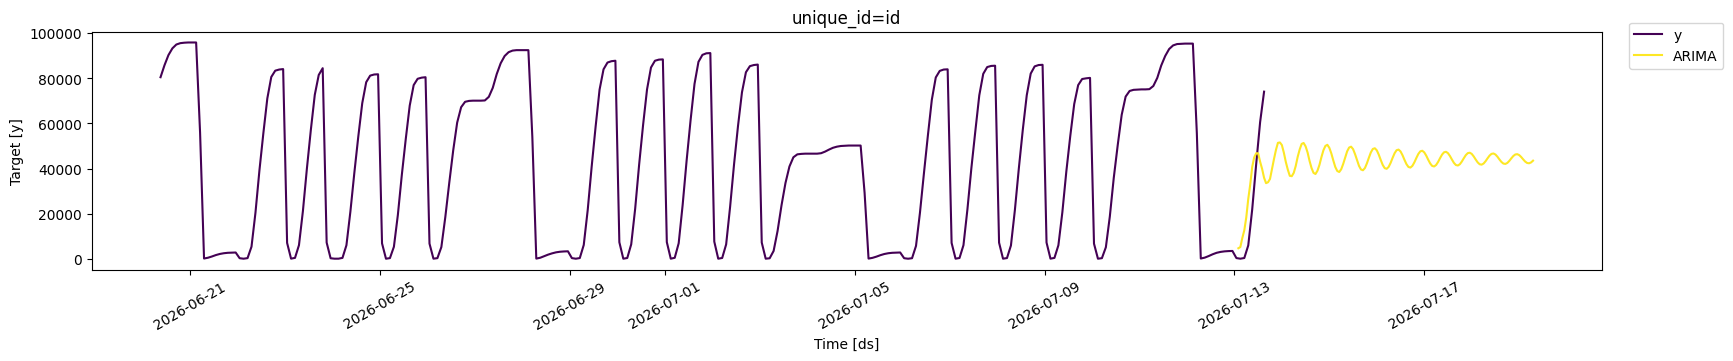

In [ ]:
plot_series(
    df=df,
    forecasts_df=arima_preds,
    ids=["id"],
    max_insample_length=280,
    palette="viridis")